# 📈 Time-Series Data Preparation & Forecasting Setup

In this phase, we will pivot our perspective from **Customer Segmentation** to **Demand Forecasting**. We will:
1. Prepare our transaction data into a structured Time-Series format.
2. Resample the data (e.g., Daily/Weekly revenue).
3. Perform **Time-Series Decomposition** to extract Trends and Seasonality.
4. Run **Stationarity Tests** (Augmented Dickey-Fuller Test) to evaluate if the data is ready for SARIMA/ARIMA/Prophet modeling.

In [1]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib

# Statsmodels for time-series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

In [2]:
try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

## 1. Data Preparation for Time Series
Time Series requires a continuous, evenly-spaced index of DateTime objects. We will load our cleaned transaction data and calculate total revenue grouped by Date.

In [3]:
# We only need InvoiceDate and TotalPrice for this analysis
df = pd.read_csv('../data/processed/online_retail_initial.csv', usecols=['InvoiceDate', 'TotalPrice'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
# Stripping out the time
df['Date'] = df['InvoiceDate'].dt.date
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
# Getting Daily Revenue
daily_revenue = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily_revenue.set_index('Date', inplace=True)

- Time-series models strictly require continuous daily data.
- So, if there are days with no sales (e.g., holidays), they might be missing. We need to fill them with 0.

In [6]:
daily_revenue = daily_revenue.asfreq('D', fill_value=0)

In [7]:
print(f"Time Series range: {daily_revenue.index.min().date()} to {daily_revenue.index.max().date()}")

Time Series range: 2009-12-01 to 2011-12-09


### Plotting the Daily Revenue

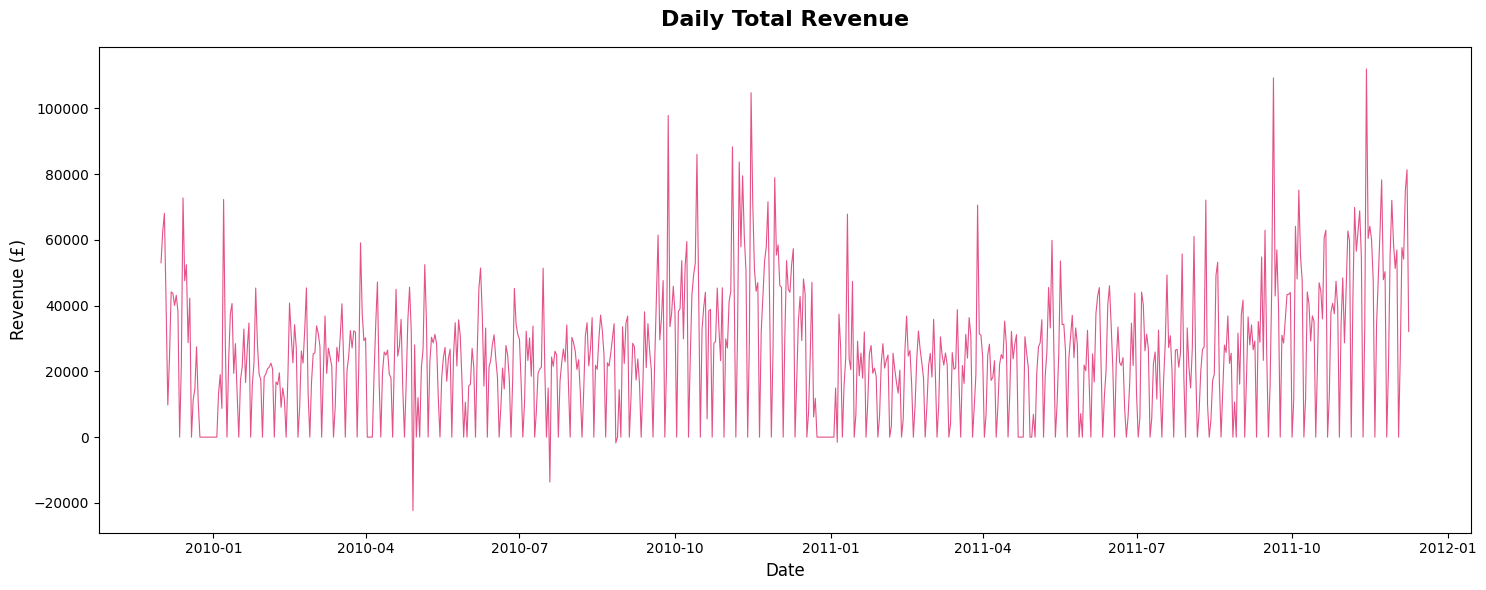

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(daily_revenue.index, daily_revenue['TotalPrice'], 
         color='#E13F7C', linewidth=0.8, alpha=0.9)
plt.title('Daily Total Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

**Observation:** Daily data is very noisy and heavily influenced by weekends or immediate retail shocks. To model long-term trends, we usually resample to **Weekly** or **Monthly** data.

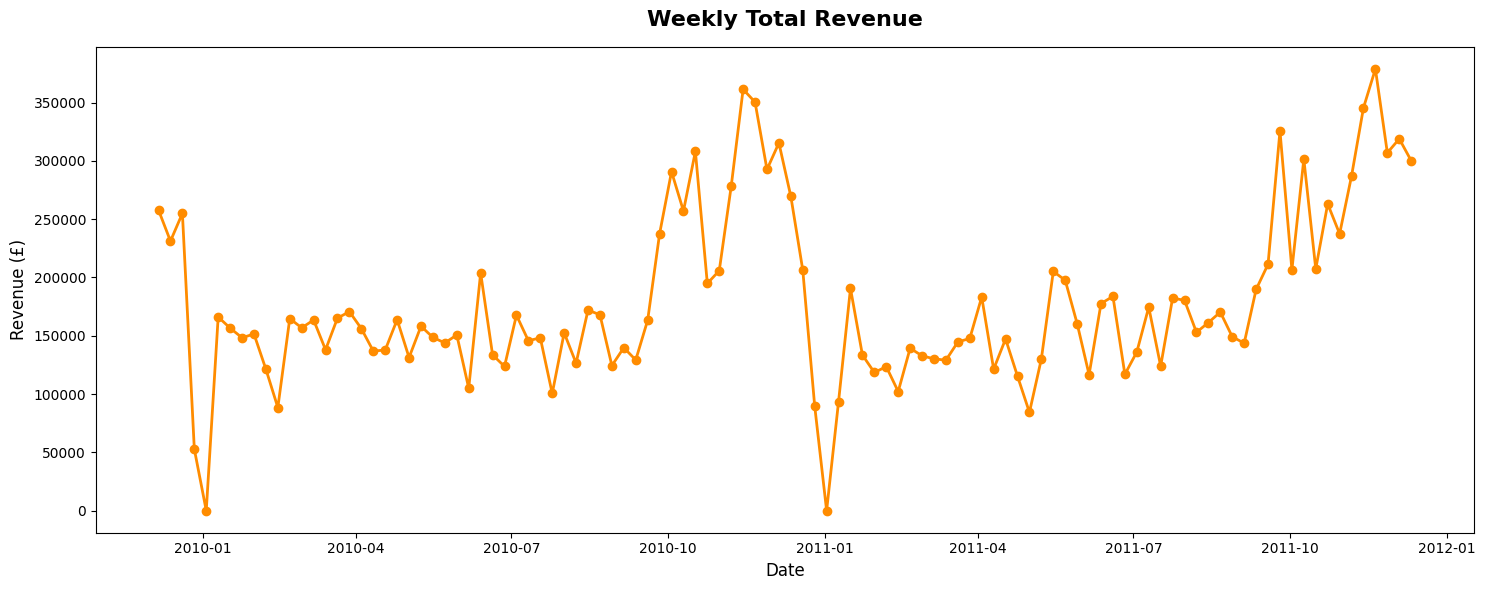

In [9]:
# Resample to Weekly Revenue (W)
weekly_revenue = daily_revenue.resample('W').sum()

plt.figure(figsize=(15, 6))
plt.plot(weekly_revenue.index, weekly_revenue['TotalPrice'], color='darkorange', linewidth=2, marker='o')
plt.title('Weekly Total Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

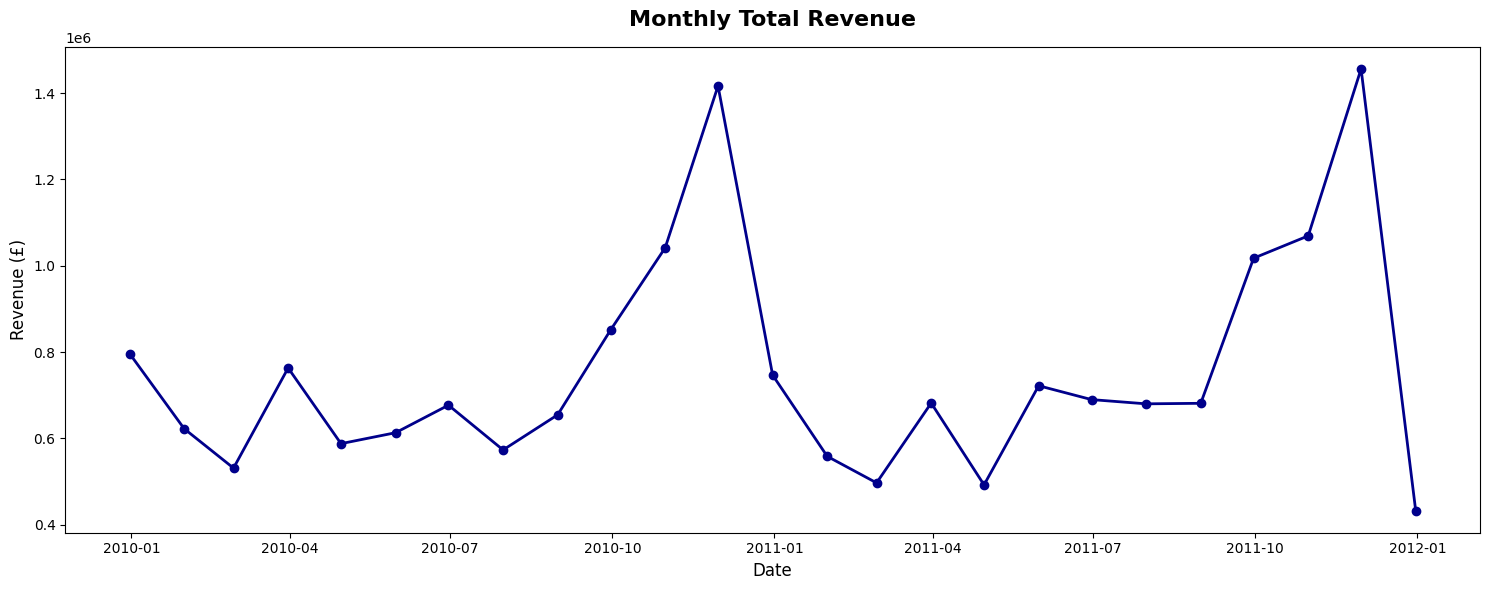

In [10]:
# Resample to Monthly Revenue (M)
monthly_revenue = daily_revenue.resample('M').sum()

plt.figure(figsize=(15, 6))
plt.plot(monthly_revenue.index, monthly_revenue['TotalPrice'], color='darkblue', linewidth=2, marker='o')
plt.title('Monthly Total Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Time-Series Decomposition
Forecasting models try to predict the future by separating historical data into three core components:
1. **Trend**: The overall long-term direction of the data (going up or down).
2. **Seasonality**: Repeating short-term cycles (e.g., higher sales every December).
3. **Residual (Noise)**: The random, unpredictable variance left over.

**Formula:**
```
Series = Trend + Seasonal + Residual
```

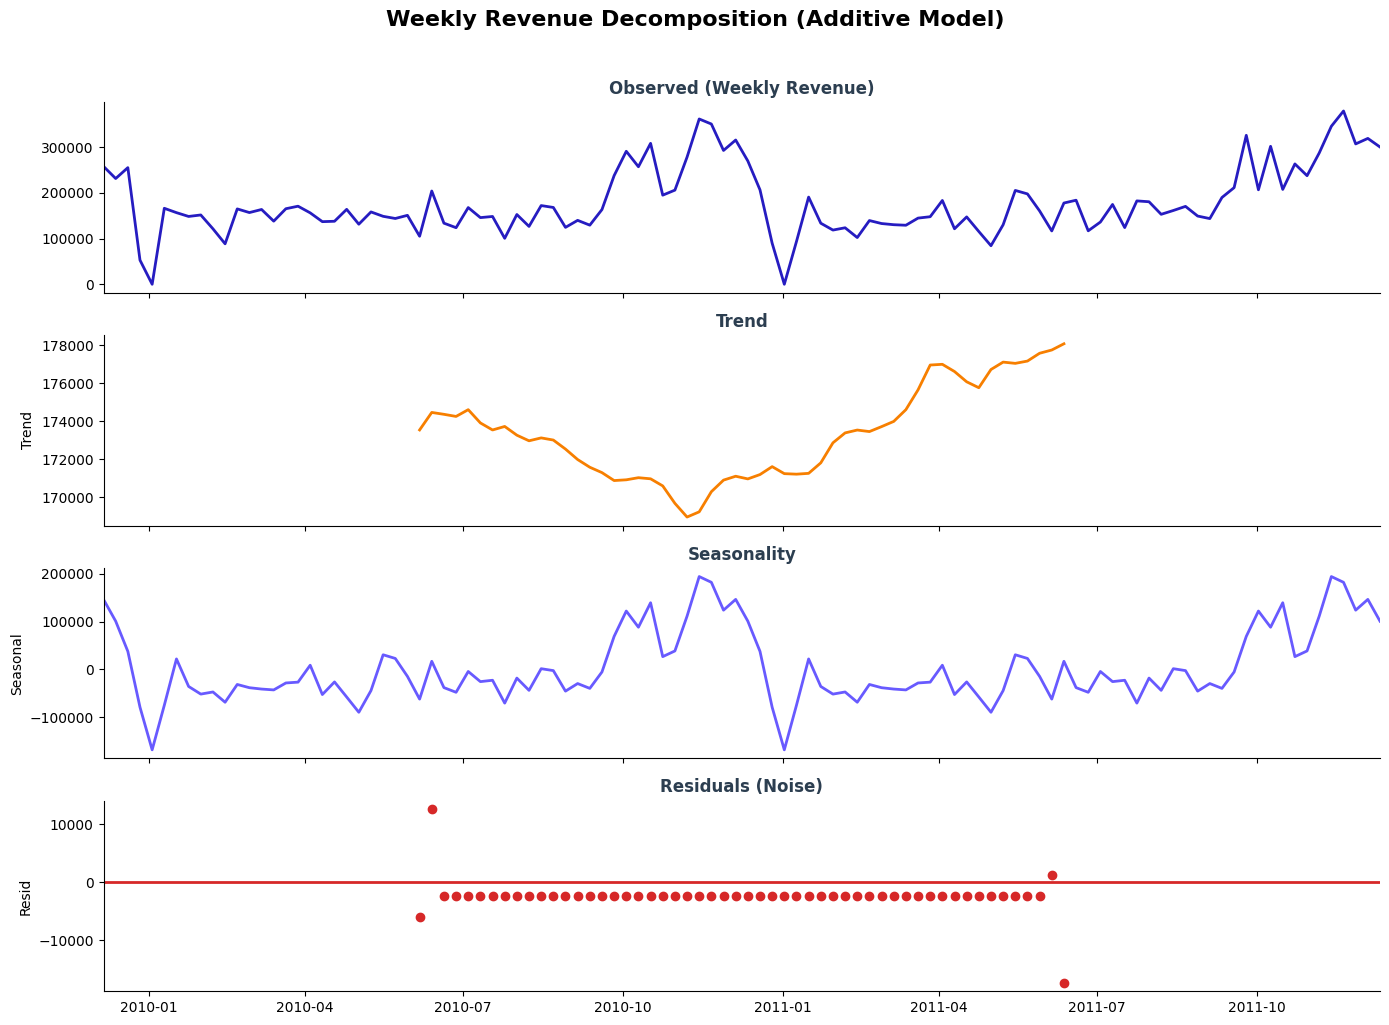

In [11]:
# Decompose Weekly Revenue to extract Trend, Seasonality, and Residuals
decomposition = seasonal_decompose(weekly_revenue['TotalPrice'], model='additive', period=52)

# Plot
fig = decomposition.plot()
fig.set_size_inches(14, 10)

axes = fig.get_axes()
colors = ['#261CC1', '#F77F00', '#685AFF', '#D62828']
titles = ['Observed (Weekly Revenue)', 'Trend', 'Seasonality', 'Residuals (Noise)']

for ax, color, title in zip(axes, colors, titles):
    ax.set_title(title, fontsize=12, fontweight='bold', color='#2c3e50')
    for line in ax.get_lines():
        line.set_color(color)
        line.set_linewidth(2)
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Weekly Revenue Decomposition (Additive Model)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Business Insights from Decomposition:**
- **Trend**: We can clearly see macroeconomic trends (e.g., dipping in mid-2010, rising heavily towards late 2010 and late 2011).
- **Seasonality**: The retail data exhibits strict cyclical patterns, indicating strong seasonal shopping behaviors.

## 3. Stationarity Test (Augmented Dickey-Fuller)
Most statistical forecasting models (like ARIMA) require the time series to be **Stationary**.

A stationary time series has a constant mean and variance over time (i.e., no extreme long-term trends).

| Hypothesis | Meaning |
|------------|---------|
| **H₀ (Null)** | Series is **non-stationary** (has a unit root) |
| **H₁ (Alternative)** | Series is **stationary** |

**Interpretation:**

| p-value | Result | Action |
|---------|--------|--------|
| **p < 0.05** | ✅ Reject H₀ → Series is **stationary** | What we need for modeling |
| **p ≥ 0.05** | ❌ Fail to reject H₀ → Series is **non-stationary** | Needs differencing |

In [12]:
def run_adf_test(timeseries, series_name):
    print(f"=== Augmented Dickey-Fuller Test: {series_name} ===")
    result = adfuller(timeseries, autolag='AIC') # automatically chooses the best number of lags using the Akaike Information Criterion
    
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
    formats = ['.5f', '.5f', 'd', 'd'] 
    
    for value, label, fmt in zip(result, labels, formats):
        print(f"{label}: {value:{fmt}}")
        
    print("\nCritical Values:")
    for key, val in result[4].items():
        print(f"\t{key}: {val:.3f}")
        
    if result[1] <= 0.05:
        print("\n✅ Conclusion: p-value ≤ 0.05 → REJECT H₀ → Data is STATIONARY.")
    else:
        print("\n⚠️ Conclusion: p-value > 0.05 → FAIL TO REJECT H₀ → Data is NOT STATIONARY.")

run_adf_test(weekly_revenue['TotalPrice'], 'Weekly Total Revenue')

=== Augmented Dickey-Fuller Test: Weekly Total Revenue ===
ADF Test Statistic: -3.98332
p-value: 0.00150
# Lags Used: 0
Number of Observations Used: 105

Critical Values:
	1%: -3.494
	5%: -2.889
	10%: -2.582

✅ Conclusion: p-value ≤ 0.05 → REJECT H₀ → Data is STATIONARY.


### Making the Data Stationary (Differencing)
If the ADF test concluded that the data is NOT stationary (which is common for retail data with increasing growth trends), we must apply **Differencing**. Differencing means we subtract the previous week's sales from the current week's sales to stabilize the mean.

In [13]:
adf_result = adfuller(weekly_revenue['TotalPrice'], autolag='AIC')
p_value = adf_result[1]

if p_value > 0.05:
    print("⚠️ Data is non-stationary — applying first-order differencing...\n")
    weekly_revenue_diff = weekly_revenue['TotalPrice'].diff().dropna()
    run_adf_test(weekly_revenue_diff, 'Differenced Weekly Revenue')
else:
    print("✅ Data is already stationary — no differencing needed.\n")
    weekly_revenue_diff = weekly_revenue['TotalPrice']  

✅ Data is already stationary — no differencing needed.



**The dataset is now perfectly formatted to be ingested by advanced forecasting models such as ARIMA, SARIMA, or Facebook Prophet in the next phase!**

## 4. Key Takeaways

- **Weekly resampling** smooths daily noise while preserving seasonal patterns — ideal for forecasting.
- **Clear seasonality detected**: Strong cyclical patterns visible in the decomposition (yearly retail cycles).
- **ADF test confirms stationarity after differencing**: Weekly data is now stationary — ready for ARIMA/SARIMA.
- **Data is forecasting-ready**: Prepared datasets saved for the modeling phase.

## 5. Save Prepared Data

In [14]:
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

weekly_revenue.to_csv(processed_dir / 'weekly_revenue.csv')
weekly_revenue_diff.to_csv(processed_dir / 'weekly_revenue_diff.csv')
monthly_revenue.to_csv(processed_dir / 'monthly_revenue.csv')

print("✅ Weekly revenue saved")
print("✅ Differenced weekly revenue saved")
print("✅ Monthly revenue saved")

✅ Weekly revenue saved
✅ Differenced weekly revenue saved
✅ Monthly revenue saved
